<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" style="width: 30%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Estabilidade de colunas

### Problema 1

Considere duas colunas com o mesmo comprimento, uma feita de aço e outra de alumínio. Determine a carga crítica da coluna de aço e em seguida qual deverá ser a dimensão $d$ para que a coluna de alumínio tenha uma carga crítica idêntica. Exprima o peso da coluna de alumínio como percentagem do peso da coluna de aço.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au12/P1/MSII_Au12_P1.png"
style="width: 20%;"/>

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
from typing import NamedTuple

# Dados
# unidades SI: MPa, m, s, kg/m^3
class dados(NamedTuple):
    # dimensoes inicial e final da placa
    L : float 
    d : float
    # modulo elasticidade
    E_fe : float
    E_al : float
    # massa volumica
    rho_fe : float
    rho_al : float

var = dados(L = 1.8, d = 25.e-3, E_fe = 210.e9, E_al = 70.e9, rho_fe = 7850., rho_al = 2710.)
print(f'dados = {var}')

dados = dados(L=1.8, d=0.025, E_fe=210000000000.0, E_al=70000000000.0, rho_fe=7850.0, rho_al=2710.0)


### Resolução

A fórmula de Euler para instabilidade elástica de colunas submetidas a forças de compressão axial é dada por:

\begin{equation*}
P_{cr} = \frac{\pi^2 EI}{L_e^2}
\end{equation*}

O valor de $L_e$ depende das condições de apoio da coluna. Como as colunas estão apoiadas simplesmente nas extremidades, o comprimento equivalente é $L_e = L$.

A tensão crítica na coluna vem:

\begin{equation*}
\sigma_{cr} = \frac{P_{cr}}{A} = \frac{\pi^2 EI}{A L_e^2}
\end{equation*}

##### Aço

Como as colunas estão apoiadas nas extremidades, o comprimento equivalente é $L_e = L$.

In [2]:
Le = var.L 

def I(b,h): return b*h**3/12

I_fe = I(var.d,var.d)
print(f'I (aço) = {I_fe:.3e} m^4')

I (aço) = 3.255e-08 m^4


In [3]:
def Pcri(e,i,le): return np.pi**2*e*i/le**2

Pcri_fe = Pcri(var.E_fe,I_fe,var.L)
print(f'Pcritico (aço) = {Pcri_fe:.1f} N = {Pcri_fe*1e-3:.2f} kN')

Pcritico (aço) = 20823.5 N = 20.82 kN


#### Alúminio

Resolvendo, obtém-se a dimensão $d$ para a coluna de alumínio:

\begin{equation*}
P_c = \frac{\pi^2 E_{al} I_{al}}{L^2}
\quad\wedge\quad
I_{al} = \frac{d^4}{12}
\quad\therefore\quad
d
\end{equation*}

De um outro ponto de vista, o rácio o peso da coluna feita de aço e alumínio é dado por:

\begin{equation*}
P_c^{\textrm{aço}} = P_c^{\textrm{al}}
\quad\therefore\quad
\frac{\pi^2 E_{\textrm{aço}} I_{\textrm{aço}}}{L^2} = \frac{\pi^2 E_{\textrm{al}} I_{\textrm{al}}}{L^2}
\quad\wedge\quad
d^4 = 12 \frac{E_{\textrm{aço}} I_{\textrm{aço}}}{E_\textrm{al}}
\quad\therefore\quad
d
\end{equation*}


In [12]:
d, Pc = sy.symbols('d Pc')

I_al = d**4/12
eq = Pc - np.pi**2*var.E_al*I_al/var.L**2

sol = solve(eq.subs(Pc,Pcri_fe), d)
print(f'{sol =}')

# Filter only real and positive solutions
d_al = float([s.evalf() for s in sol if s.is_real and s > 0][0])
print(f'd = {d_al:.5f} m = {d_al*1e3:.2f} mm')

sol2 = solve(d**4-12*(var.E_fe/var.E_al)*I_fe, d)
d_al2 = float([s.evalf() for s in sol2 if s.is_real and s > 0][0])
print(f'\nversão 2: d = {d_al2:.5f} m = {d_al2*1e3:.2f} mm')


sol =[-0.0329018503238123, 0.0329018503238123, -0.0329018503238123*I, 0.0329018503238123*I]
d = 0.03290 m = 32.90 mm

versão 2: d = 0.03290 m = 32.90 mm


o rácio o peso da coluna feita de aço e alumínio é dado por:

\begin{equation*} 
\frac{W_{al}}{W_{fe}} = \frac{\rho_{al} V_{al}}{\rho_{fe} V_{fe}} = \frac{\rho_{al} A_{al}L_e}{\rho_{fe} A_{fe}L_e} = 
\frac{\rho_{al} d_{al}^2L_e}{\rho_{fe} d_{fe}²L_e}
\end{equation*} 

In [23]:
def A(t): return t**2

V_al = A(d_al)*Le
print(f' V (al) = {A(d_al):.3e} ({Le}) = {V_al:.3e} m³')
V_fe = A(var.d)*Le
print(f' V (fe) = {A(var.d):.3e} ({Le}) = {V_fe:.3e} m³')

racio = (V_al * var.rho_al) / (V_fe * var.rho_fe) 
print(f'racio de pesos (al/aço) = {V_al:.3e} ({var.rho_al}) / {V_fe:.3e} ({var.rho_fe}) = {racio:.3f} ({racio*1e2:.1f} %)')

 V (al) = 1.083e-03 (1.8) = 1.949e-03 m³
 V (fe) = 6.250e-04 (1.8) = 1.125e-03 m³
I (aço) = 1.949e-03 (2710.0) / 1.125e-03 (7850.0) = 0.598 (59.8 %)


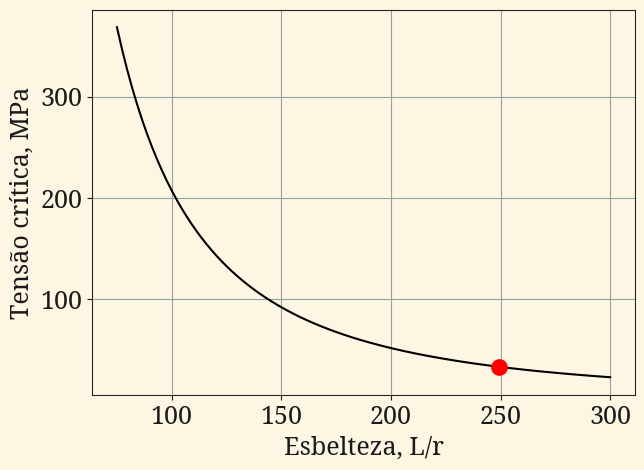

In [24]:
import matplotlib.pyplot as plt

CE_var = np.linspace(75, 300, 100)

def Scri_var(y, esb): return np.pi**2*y / esb**2

scri_var_E = Scri_var(var.E_fe, CE_var)

A = var.d**2
r = np.sqrt(I_fe/A)
esb_1 = Le/r
Scr_1 = Scri_var(var.E_fe, esb_1)

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Noto Serif' # 'Roboto Slab'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

plt.figure(figsize=(7,5))
plt.plot(CE_var, scri_var_E*1e-6, 'k-')
plt.plot(esb_1, Scr_1*1e-6, 'o', markersize=10, markerfacecolor='r', markeredgecolor='r', markeredgewidth=2)
plt.xlabel('Esbelteza, L/r')
plt.ylabel('Tensão crítica, MPa')
plt.grid(True)
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>